# 01 - Exploratory Data Analysis
Car Price Prediction Challenge dataset

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Load the Dataset

In [15]:
df = pd.read_csv('../data/raw/car.csv')
df.shape

(19237, 18)

In [16]:
df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  str    
 3   Manufacturer      19237 non-null  str    
 4   Model             19237 non-null  str    
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  str    
 7   Leather interior  19237 non-null  str    
 8   Fuel type         19237 non-null  str    
 9   Engine volume     19237 non-null  str    
 10  Mileage           19237 non-null  str    
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  str    
 13  Drive wheels      19237 non-null  str    
 14  Doors             19237 non-null  str    
 15  Wheel             19237 non-null  str    
 16  Color             19237 non-null  str    
 17  Airb

In [18]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,19237.0,NaN,NaN,NaN,45576535.886105,936591.422799,20746880.0,45698374.0,45772308.0,45802036.0,45816654.0
Price,19237.0,NaN,NaN,NaN,18555.927224,190581.269684,1.0,5331.0,13172.0,22075.0,26307500.0
Levy,19237,559,-,5819,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Manufacturer,19237,65,HYUNDAI,3769,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,19237,1590,Prius,1083,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Prod. year,19237.0,NaN,NaN,NaN,2010.912824,5.668673,1939.0,2009.0,2012.0,2015.0,2020.0
Category,19237,11,Sedan,8736,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Leather interior,19237,2,Yes,13954,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fuel type,19237,7,Petrol,10150,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Engine volume,19237,107,2,3916,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data quality checks
- `Levy` uses `-` for missing values (not NaN)
- `Doors` has corrupted Excel-range values
- `Engine volume` mixes numeric + 'Turbo' text
- `Mileage` is stored as string with ' km' suffix
- Exact duplicate rows exist

In [19]:
print('Duplicate rows:', df.duplicated().sum())
print('Levy "-" count:', (df['Levy'] == '-').sum())
print('Doors unique:', df['Doors'].unique())
print('Engine volume sample:', df['Engine volume'].unique()[:10])

Duplicate rows: 313
Levy "-" count: 5819
Doors unique: <ArrowStringArray>
['04-May', '02-Mar', '>5']
Length: 3, dtype: str
Engine volume sample: <ArrowStringArray>
['3.5', '3', '1.3', '2.5', '2', '1.8', '2.4', '4', '1.6', '3.3']
Length: 10, dtype: str


## 3. Target variable: Price

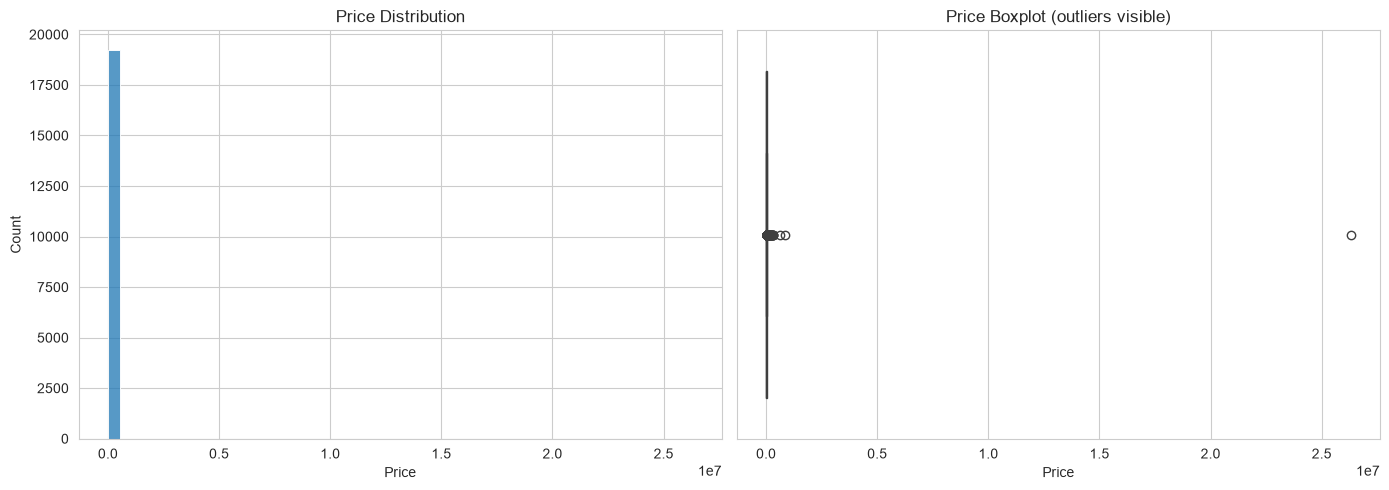

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Price'], bins=50, ax=axes[0])
axes[0].set_title('Price Distribution')

sns.boxplot(x=df['Price'], ax=axes[1])
axes[1].set_title('Price Boxplot (outliers visible)')
plt.tight_layout()
plt.savefig('../reports/charts/price_distribution.png', dpi=150)
plt.show()

In [21]:
print(df['Price'].describe())
print()
print('Price == 0 count:', (df['Price'] == 0).sum())
print('Top 1% price threshold:', df['Price'].quantile(0.99))

count    1.923700e+04
mean     1.855593e+04
std      1.905813e+05
min      1.000000e+00
25%      5.331000e+03
50%      1.317200e+04
75%      2.207500e+04
max      2.630750e+07
Name: Price, dtype: float64

Price == 0 count: 0
Top 1% price threshold: 84675.0


**Insight:** Price is heavily right-skewed with extreme outliers (some 0, some far above the 99th percentile). Consider capping or log-transforming for modeling.

## 4. Univariate: categorical features

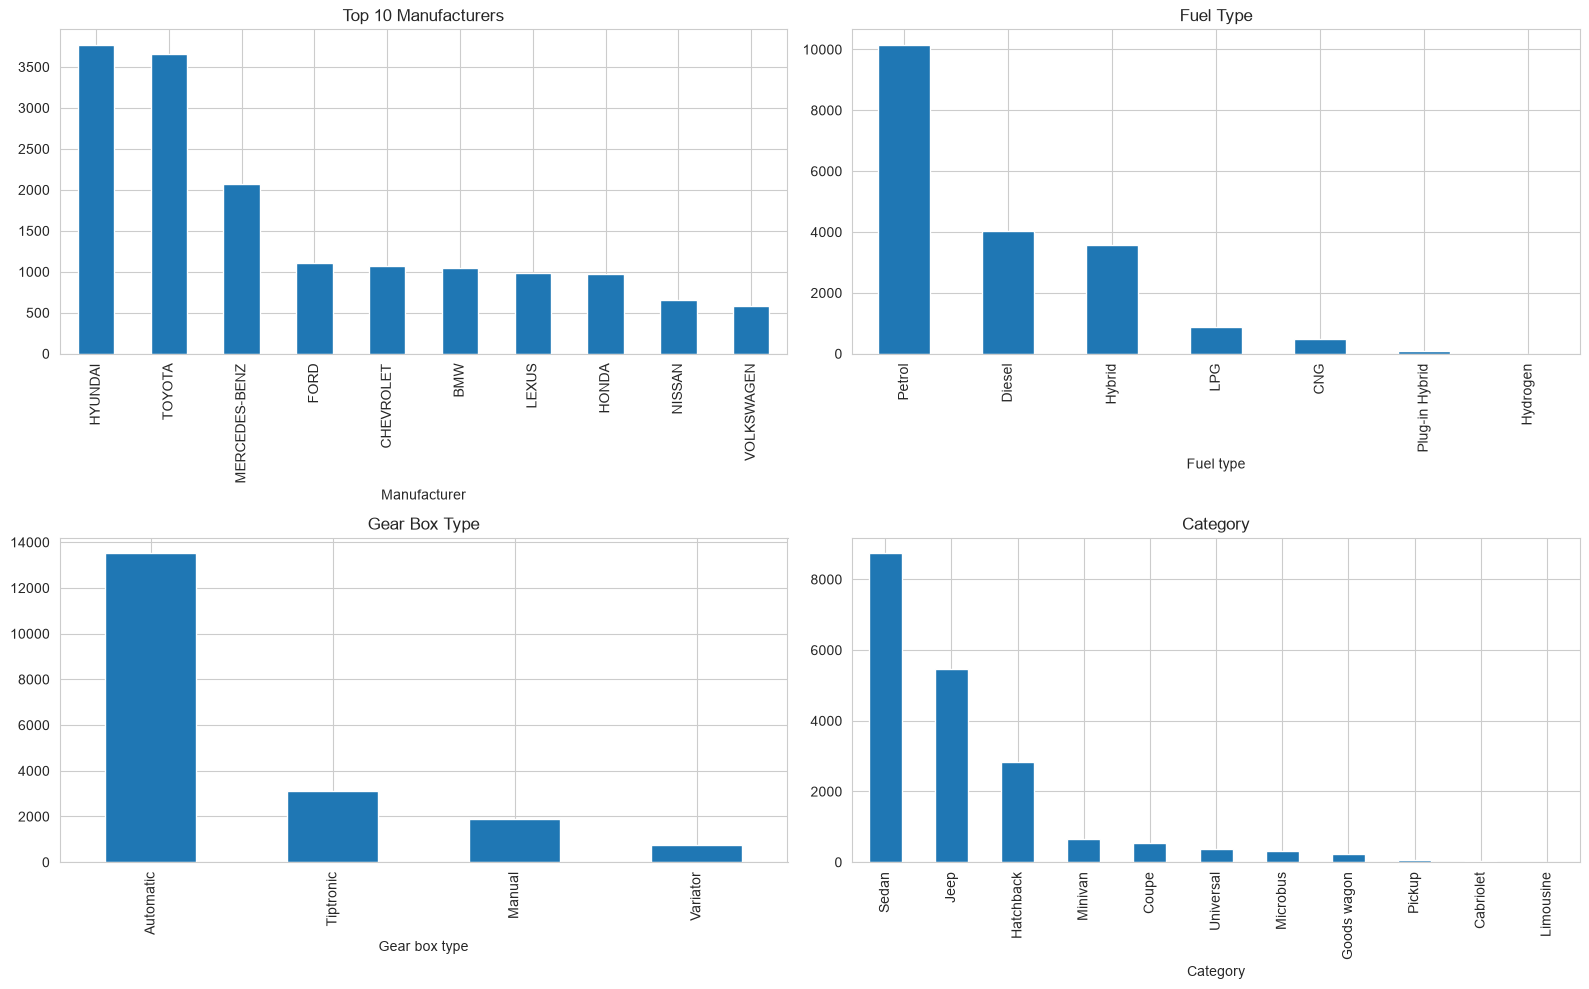

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

df['Manufacturer'].value_counts().head(10).plot(kind='bar', ax=axes[0,0], title='Top 10 Manufacturers')
df['Fuel type'].value_counts().plot(kind='bar', ax=axes[0,1], title='Fuel Type')
df['Gear box type'].value_counts().plot(kind='bar', ax=axes[1,0], title='Gear Box Type')
df['Category'].value_counts().plot(kind='bar', ax=axes[1,1], title='Category')

plt.tight_layout()
plt.savefig('../reports/charts/categorical_distributions.png', dpi=150)
plt.show()

## 5. Bivariate: Price vs key features

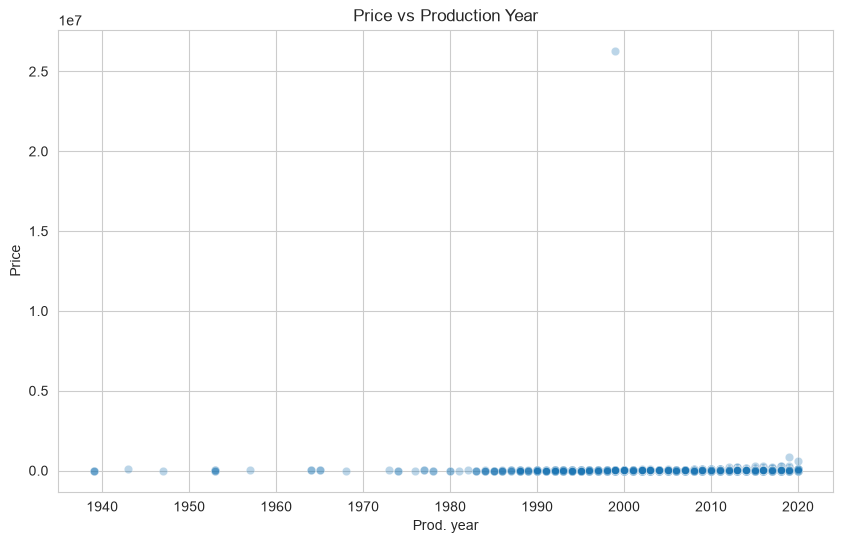

In [23]:
# Price vs Production Year
plt.figure()
sns.scatterplot(data=df, x='Prod. year', y='Price', alpha=0.3)
plt.title('Price vs Production Year')
plt.savefig('../reports/charts/price_vs_year.png', dpi=150)
plt.show()

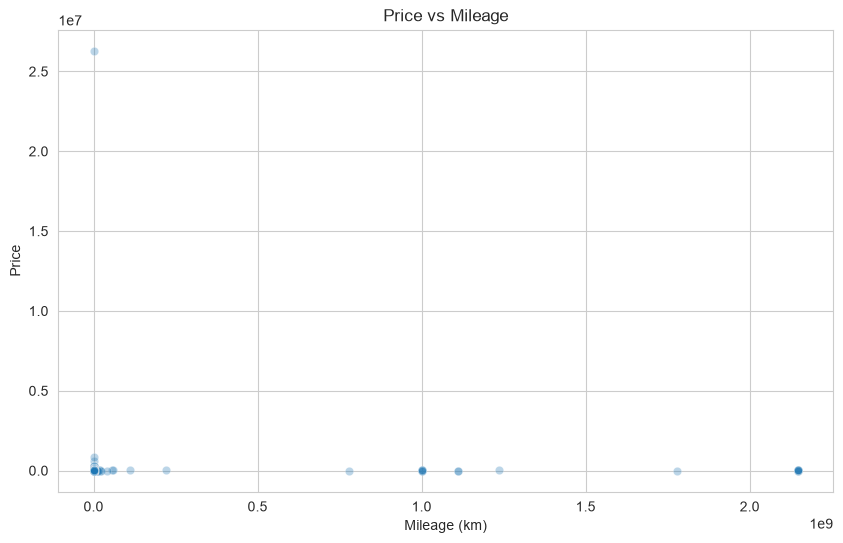

In [24]:
# Price vs Mileage (clean the km string first, just for plotting)
mileage_clean = df['Mileage'].str.replace(' km', '', regex=False).astype(int)
plt.figure()
sns.scatterplot(x=mileage_clean, y=df['Price'], alpha=0.3)
plt.title('Price vs Mileage')
plt.xlabel('Mileage (km)')
plt.savefig('../reports/charts/price_vs_mileage.png', dpi=150)
plt.show()

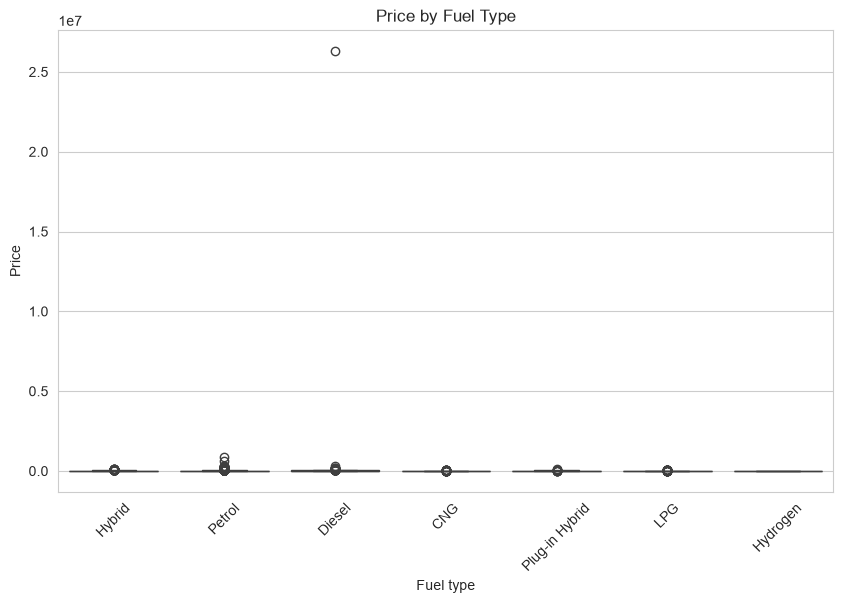

In [25]:
# Price by Fuel Type
plt.figure()
sns.boxplot(data=df, x='Fuel type', y='Price')
plt.xticks(rotation=45)
plt.title('Price by Fuel Type')
plt.savefig('../reports/charts/price_by_fueltype.png', dpi=150)
plt.show()

**Insight:** Newer production years generally trend toward higher price, though heavy outliers distort the picture. Mileage shows the expected inverse relationship with price.

## 6. Correlation heatmap (numeric features)

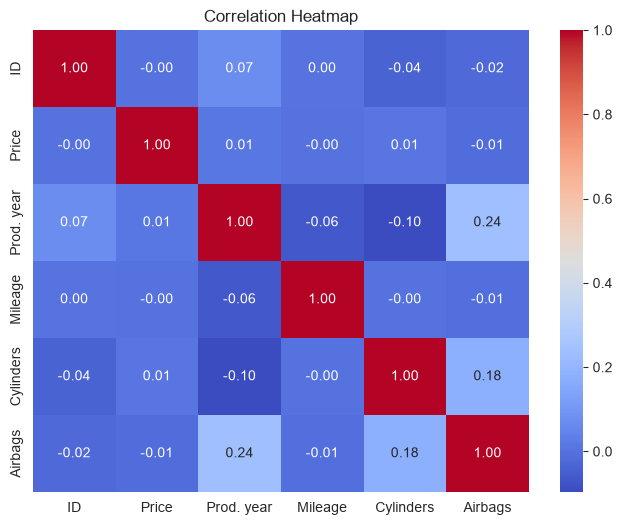

: 

In [ ]:
numeric_df = df.copy()
numeric_df['Mileage'] = mileage_clean
numeric_df = numeric_df.select_dtypes(include=[np.number])

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.savefig('../reports/charts/correlation_heatmap.png', dpi=150)
plt.show()

## 7. Summary of findings

- Dataset: 19,237 rows x 18 columns, no true NaNs but hidden missing markers
- `Levy` needs `-` -> NaN conversion
- `Doors` needs re-mapping (Excel corrupted the ranges)
- `Engine volume` needs splitting into numeric + turbo flag
- `Mileage` needs string cleanup to int
- 313 duplicate rows to drop
- `Price` is heavily skewed with outliers -> capping/log-transform candidate for modeling

Next notebook: `02_Preprocessing.ipynb` handles all of the above.